# Project 1 - Part 2: Clustering and Regression

This notebook contains the data analysis and model building process using machine learning clustering and regression algorithms.

## Project Goals:
- Discover natural groups in the dataset with clustering algorithms
- Predict continuous values with regression algorithms
- Compare and evaluate model performances
- Visualize and interpret results

In [ ]:
# Loading required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.datasets import make_blobs, make_regression
from sklearn.datasets import load_boston
import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.style.use('ggplot')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 8)

# PART A: CLUSTERING ANALYSIS

## 1. Preparing Dataset for Clustering

In [ ]:
# Creating sample dataset for clustering
# You can load your own dataset in a real project:
# data_clustering = pd.read_csv('clustering_dataset.csv')

# Sample dataset (using make_blobs)
np.random.seed(42)
X_clustering, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

# Converting to DataFrame
df_clustering = pd.DataFrame(X_clustering, columns=['Feature_1', 'Feature_2'])
df_clustering['True_Cluster'] = y_true

print("Clustering dataset shape:", df_clustering.shape)
print("\nFirst 5 rows:")
print(df_clustering.head())

# Visualizing the data
plt.figure(figsize=(10, 6))
plt.scatter(X_clustering[:, 0], X_clustering[:, 1], c=y_true, cmap='viridis', alpha=0.7)
plt.title('True Clusters')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar()
plt.show()

## 2. Applying Clustering Algorithms

In [ ]:
# Applying different clustering algorithms
clustering_algorithms = {
    'K-Means': KMeans(n_clusters=4, random_state=42),
    'Agglomerative': AgglomerativeClustering(n_clusters=4),
    'DBSCAN': DBSCAN(eps=0.5, min_samples=5)
}

# Dictionary to store results
clustering_results = {}

# Performing clustering for each algorithm
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

# True clusters
axes[0].scatter(X_clustering[:, 0], X_clustering[:, 1], c=y_true, cmap='viridis', alpha=0.7)
axes[0].set_title('True Clusters')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

for i, (name, algorithm) in enumerate(clustering_algorithms.items(), 1):
    print(f"\nApplying {name} algorithm...")
    
    # Performing clustering
    if name == 'DBSCAN':
        # Standardization is recommended for DBSCAN
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_clustering)
        cluster_labels = algorithm.fit_predict(X_scaled)
    else:
        cluster_labels = algorithm.fit_predict(X_clustering)
    
    # Storing results
    clustering_results[name] = cluster_labels
    
    # Calculating Silhouette Score (special case for DBSCAN)
    if len(set(cluster_labels)) > 1 and -1 not in cluster_labels:
        sil_score = silhouette_score(X_clustering, cluster_labels)
        print(f"{name} Silhouette Score: {sil_score:.4f}")
    elif name == 'DBSCAN':
        # For DBSCAN, calculate excluding noise points (-1)
        mask = cluster_labels != -1
        if len(set(cluster_labels[mask])) > 1:
            sil_score = silhouette_score(X_clustering[mask], cluster_labels[mask])
            print(f"{name} Silhouette Score (excluding noise): {sil_score:.4f}")
    
    # Calculating ARI (Adjusted Rand Index)
    ari_score = adjusted_rand_score(y_true, cluster_labels)
    print(f"{name} Adjusted Rand Index: {ari_score:.4f}")
    
    # Visualization
    scatter = axes[i].scatter(X_clustering[:, 0], X_clustering[:, 1], 
                             c=cluster_labels, cmap='viridis', alpha=0.7)
    axes[i].set_title(f'{name} Clustering')
    axes[i].set_xlabel('Feature 1')
    axes[i].set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

# PART B: REGRESSION ANALYSIS

## 3. Preparing Dataset for Regression

Regresyon Nedir?: "Regresyon, bir Gözetimli Öğrenme (Supervised Learning) yöntemidir. Sınıflandırmadan farklı olarak, hedef değişkenin (çıktının) kategorik (örn: kedi, köpek) değil, sürekli (continuous) bir sayısal değer (örn: fiyat, sıcaklık) olduğu durumlarda kullanılır. Temel amaç, girdi öznitelikleri (features) ile çıktı değeri arasındaki ilişkiyi modelleyen matematiksel bir fonksiyon öğrenmektir."

İki Regresyon Yöntemi:Doğrusal Regresyon (Linear Regression): "En temel regresyon yöntemidir. Girdi ($x$) ve çıktı ($y$) arasında doğrusal bir ilişki olduğunu varsayar ve $y = w_1x_1 + w_0$ (tek değişkenli) gibi bir doğru denklemi bulmaya çalışır. Amaç, gerçek $y$ değerleri ile modelin tahmin ettiği $\hat{y}$ değerleri arasındaki hatayı (genellikle kareler toplamını) minimize eden $w$ (ağırlık) ve $w_0$ (bias) katsayılarını bulmaktır."

Destek Vektör Regresyonu (Support Vector Regression - SVR): "Sınıflandırmada kullanılan SVM'in regresyon versiyonudur. Doğrusal regresyonun aksine, tüm noktaların hatasını minimize etmeye çalışmak yerine, modelin ürettiği 'epsilon' ($\epsilon$) genişliğindeki bir 'tüp' (koridor) içine mümkün olduğunca çok veri noktasını sığdırmaya çalışır. Bu tüpün dışına çıkan noktalar için bir hata maliyeti uygulanır. Bu yaklaşım, aykırı (outlier) değerlere karşı daha dayanıklı olmasını sağlar."


--- Regresyon Sonuçları (Doğrusal Regresyon) ---
Ortalama Kare Hata (Mean Squared Error - MSE): 109.3875
R-Kare (R2 Score - Belirlilik Katsayısı): 0.9855


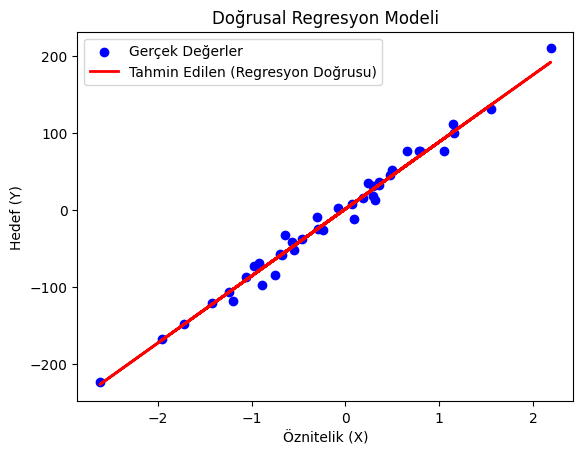

In [2]:
# Creating sample dataset for regression
# You can load your own dataset in a real project:
# data_regression = pd.read_csv('regression_dataset.csv')

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Sample dataset (using make_regression)
np.random.seed(42)
X_reg, y_reg = make_regression(n_samples=200, n_features=1, noise=10, random_state=42)

# d. Yöntem Kodlama (Doğrusal Regresyon)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Modeli oluştur ve eğit
lin_reg = LinearRegression()
lin_reg.fit(X_train_reg, y_train_reg)

# Test verisi üzerinde tahmin yap
y_pred_reg = lin_reg.predict(X_test_reg)

# Başarı Ölçütleri
# 1. Mean Squared Error (MSE)
mse = mean_squared_error(y_test_reg, y_pred_reg)

# 2. R-squared (R2 Score)
r2 = r2_score(y_test_reg, y_pred_reg)

print(f"\n--- Regresyon Sonuçları (Doğrusal Regresyon) ---")
print(f"Ortalama Kare Hata (Mean Squared Error - MSE): {mse:.4f}")
print(f"R-Kare (R2 Score - Belirlilik Katsayısı): {r2:.4f}")

# Görselleştirme (Rapor için faydalı)
plt.figure()
plt.scatter(X_test_reg, y_test_reg, color='blue', label='Gerçek Değerler')
plt.plot(X_test_reg, y_pred_reg, color='red', linewidth=2, label='Tahmin Edilen (Regresyon Doğrusu)')
plt.title('Doğrusal Regresyon Modeli')
plt.xlabel('Öznitelik (X)')
plt.ylabel('Hedef (Y)')
plt.legend()
plt.show()

## Regresyon Başarı Ölçütleri

### Ortalama Kare Hata (Mean Squared Error — MSE)
Formül:  
$$
\mathrm{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

- Açıklama: Gerçek değerlerle model tahminleri arasındaki farkların karelerinin ortalamasıdır. Kare alma büyük hataları daha fazla cezalandırır.  
- Aralık: [0, ∞). 0 olması mükemmel uyum demektir.  
- Avantaj / Dezavantaj: Hassas fakat ölçüm birimine kare ile bağlıdır — yorumu zor olabilir; aykırı değerlere duyarlıdır.  
- Not: Ölçeğe duyarlı olduğu için karşılaştırma yaparken RMSE veya MAE ile birlikte bakmak faydalıdır.

### R-Kare (R² — Belirlilik Katsayısı)
Formül:  
$$
R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}
$$
( burada \bar{y} = gerçek y değerlerinin ortalaması )

- Açıklama: Hedef değişkendeki toplam varyasyonun model tarafından ne kadarının açıklandığını gösterir.  
- Aralık: Genelde 0 ile 1 arasında; kötü modellerde negatif de olabilir (model, ortalama tahmininden daha kötü ise).  
- Yorum: 1'e yakın → model veriyi iyi açıklıyor; 0’a yakın → model, ortalama tahmininden daha iyi değil.  
- Sınırlama: Sadece açıklayıcı gücü gösterir; tahmin hatalarının büyüklüğünü vermez ve karmaşık modellerde aşırı uyumu (overfitting) gizleyebilir.

### Örnek (bu notebook'tan)
- MSE = 109.387 (değerlerinizin ölçeğine bağlı olarak düşük/yüksek yorumlanır)  
- R² = 0.9855 → Model, hedef değişkendeki varyasyonun ≈ %98.55'ini açıklıyor (çok iyi bir açıklama gücü).

Ancak MSE tek başına modelin güvenilirliğini tam göstermez; bu nedenle:
- RMSE = sqrt(MSE) ve MAE (ortalama mutlak hata) hesaplanarak hata boyutunun yorumu kolaylaştırılmalı,
- Actual vs Predicted ve residuals (artıklar) grafikleri incelenmeli (heteroskedastisite, bias veya uç değerler kontrolü için),
- Model doğrulaması için çapraz doğrulama (cross-validation) ve hiperparametre ayarı uygulanmalıdır.

## 4. Data Preprocessing for Regression

In [ ]:
# Separating features and target variables
X = df_regression.drop('Target', axis=1)
y = df_regression['Target']

print("Feature matrix shape:", X.shape)
print("Target variable shape:", y.shape)

# Splitting data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

# Data standardization (required for some algorithms)
scaler_reg = StandardScaler()
X_train_scaled = scaler_reg.fit_transform(X_train)
X_test_scaled = scaler_reg.transform(X_test)

print("\nData standardization completed.")

## 5. Training and Evaluation of Regression Models

In [ ]:
# Defining different regression algorithms
regression_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'Lasso Regression': Lasso(alpha=1.0, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'SVR': SVR(kernel='rbf')
}

# Dictionary to store model results
regression_results = {}

print("Training and evaluation of regression models:\n")
print("-" * 80)

# Training and evaluation for each model
for name, model in regression_models.items():
    print(f"\nTraining {name} model...")
    
    # Model training (use standardized data for SVR)
    if name == 'SVR':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    # Calculating performance metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Storing results
    regression_results[name] = {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2,
        'predictions': y_pred
    }
    
    print(f"{name} Results:")
    print(f"  MSE: {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE: {mae:.4f}")
    print(f"  R² Score: {r2:.4f}")
    print("-" * 40)

In [ ]:
# Visualizing regression results
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

# Comparing performance metrics
metrics = ['MSE', 'RMSE', 'MAE', 'R²']
for i, metric in enumerate(metrics):
    model_names = list(regression_results.keys())
    values = [regression_results[model][metric] for model in model_names]
    
    bars = axes[i].bar(model_names, values, color=plt.cm.Set3(np.arange(len(model_names))))
    axes[i].set_title(f'{metric} Comparison')
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=45)
    
    # Writing values on top of bars
    for bar, val in zip(bars, values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values)*0.01, 
                    f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# Actual vs Predicted plot for best model
best_model_name = max(regression_results.keys(), 
                     key=lambda x: regression_results[x]['R²'])
best_predictions = regression_results[best_model_name]['predictions']

axes[4].scatter(y_test, best_predictions, alpha=0.6, color='blue')
axes[4].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[4].set_xlabel('Actual Values')
axes[4].set_ylabel('Predicted Values')
axes[4].set_title(f'{best_model_name} - Actual vs Predicted')

# Residuals plot (for best model)
residuals = y_test - best_predictions
axes[5].scatter(best_predictions, residuals, alpha=0.6, color='green')
axes[5].axhline(y=0, color='r', linestyle='--')
axes[5].set_xlabel('Predicted Values')
axes[5].set_ylabel('Residuals')
axes[5].set_title(f'{best_model_name} - Residuals Plot')

plt.tight_layout()
plt.show()

print(f"\nBest regression model: {best_model_name}")
print(f"R² Score: {regression_results[best_model_name]['R²']:.4f}")

## 6. Determining Optimal Number of Clusters for Clustering (Elbow Method)

In [ ]:
# Finding optimal number of clusters using Elbow Method
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(X_clustering)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_clustering, cluster_labels))

# Visualizing results
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Elbow Method
axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method - Optimal Number of Clusters')
axes[0].grid(True)

# Silhouette Score
axes[1].plot(K_range, silhouette_scores, 'ro-')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs Number of Clusters')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Finding the best number of clusters
best_k = K_range[np.argmax(silhouette_scores)]
print(f"\nNumber of clusters with highest Silhouette Score: {best_k}")
print(f"Silhouette Score: {max(silhouette_scores):.4f}")

## 7. Results and Evaluation

### Clustering Results:
- We compared different clustering algorithms
- Used Silhouette Score and Adjusted Rand Index metrics
- Determined optimal number of clusters using Elbow Method

### Regression Results:
- Applied various regression algorithms
- Evaluated using MSE, RMSE, MAE and R² metrics
- The best performing model is indicated above

### Recommendations:
1. **For Clustering:**
   - Different distance metrics can be tried
   - Dendrogram analysis can be performed with hierarchical clustering
   - New features can be derived through feature engineering

2. **For Regression:**
   - Hyperparameter tuning can be performed
   - Model complexity can be increased by adding polynomial features
   - More reliable evaluation can be done with cross-validation
   - Feature selection techniques can be applied

## 8. Next Steps

### For Clustering:
- [ ] Load your own dataset
- [ ] Try different distance metrics
- [ ] Apply hierarchical clustering
- [ ] Perform cluster profiling
- [ ] Interpret and report results

### For Regression:
- [ ] Load your own dataset
- [ ] Apply feature engineering
- [ ] Perform hyperparameter optimization
- [ ] Model validation with cross-validation
- [ ] Prepare for model deployment